## RUN DLC IN THE CLUSTER

In [1]:
import os
import pandas as pd
import numpy as np
os.environ["DLClight"]="True"
import deeplabcut

ModuleNotFoundError: No module named 'deeplabcut'

Modify your config file.


In [3]:
#modify this
path ='/groups/zimmer/Ulises/code/deeplabcut_projects/'
exp= 'Head_Tail_ZIM01-Ulises-2021-11-04/'#'HeadTail-Ulises-2020-08-10/'#'pharynx-UR-2021-02-17/'#'OT_Ulises_20201017-Ulises-2020-10-17/'
path_config_file = os.path.join(path,exp)+'config.yaml'
#path_config_file=path
print(path_config_file)

#don't edit these:
VideoType = 'avi' 
videofile_path = path+exp+'videos' #Enter the list of videos or folder to analyze.
print(videofile_path)

/groups/zimmer/Ulises/code/deeplabcut_projects/Head_Tail_ZIM01-Ulises-2021-11-04/config.yaml
/groups/zimmer/Ulises/code/deeplabcut_projects/Head_Tail_ZIM01-Ulises-2021-11-04/videos


In [4]:
## Extract Frames
#much faster than extracting them locally, but somehow did not produce the files?

In [ ]:
deeplabcut.extract_frames(path_config_file,slider_width=10000)

Config file read successfully.
Do you want to extract (perhaps additional) frames for video: /groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-07-01_10-10-48_control_worm1-channel-0-bigtiff.avi ?


yes/no y


88it [00:00, 871.24it/s]

Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 1197.61  seconds.
Extracting and downsampling... 200001  frames from the video.


200001it [03:27, 962.33it/s] 


Kmeans clustering ... (this might take a while)


### Merge Datasets

In [ ]:
#If you need to merge data sets run the following function

deeplabcut.merge_datasets(path_config_file)
#not sure if it has to be run always. make sure that the iteration you want is the same on the config.yaml file

### Create training

After running this script the training dataset is created and saved in the project directory under the subdirectory 'training-datasets'

This function also creates new subdirectories under dlc-models and appends the project config.yaml file with the correct path to the training and testing pose configuration file. These files hold the parameters for training the network. Such an example file is provided with the toolbox and named as pose_cfg.yaml.

Now it is the time to start training the network!

Charlie says that the default training does not do rotate and transform.

In [3]:
#USE conda env: anaconda3-DLC-GPU
# Note: if you are using the demo data (i.e. examples/Reaching-Mackenzie-2018-08-30/), first delete the folder called dlc-models! 
#Then, run this cell. There are many more functions you can set here, including which netowkr to use!
#check the docstring for full options you can do!
deeplabcut.create_training_dataset(path_config_file, net_type='resnet_50', augmenter_type='imgaug')

##IF YOU GET AN ERROR, CHECK THAT YOU EDITED THE CONFIG PATH

The training dataset is successfully created. Use the function 'train_network' to start training. Happy training!


[(0.95,
  1,
  (array([25, 42, 35,  6, 17, 18, 31, 19,  7, 23,  8,  1,  4, 26, 49, 20, 30,
           3, 45, 27, 12, 40, 39, 38, 44, 24, 22, 34, 46, 33, 15, 36, 16, 32,
           0, 10, 43, 11,  5, 37, 47, 14, 29, 41, 48,  2, 21]),
   array([13,  9, 28])))]

## Start training:
This function trains the network for a specific shuffle of the training dataset. 

In [ ]:
#TRAINING
#let's also change the display and save_iters just in case Colab takes away the GPU... 
#if that happens, you can reload from a saved point. Typically, you want to train to 200,000 + iterations.
#more info and there are more things you can set: https://github.com/AlexEMG/DeepLabCut/blob/master/docs/functionDetails.md#g-train-the-network

deeplabcut.train_network(path_config_file, shuffle=1, displayiters=5000,saveiters=2500)

#this will run until you stop it (CTRL+C), or hit "STOP" icon, or when it hits the end (default, 1.03M iterations). 
#Whichever you chose, you will see what looks like an error message, but it's not an error - don't worry....

Config:
{'all_joints': [[0], [1]],
 'all_joints_names': ['Head', 'Tail'],
 'batch_size': 1,
 'bottomheight': 400,
 'crop': True,
 'crop_pad': 0,
 'cropratio': 0.4,
 'dataset': 'training-datasets/iteration-0/UnaugmentedDataSet_Head_Tail_ZIM01Nov4/Head_Tail_ZIM01_Ulises95shuffle1.mat',
 'dataset_type': 'imgaug',
 'deterministic': False,
 'display_iters': 1000,
 'fg_fraction': 0.25,
 'global_scale': 0.8,
 'init_weights': '/users/ulises.rey/anaconda3/envs/DLC-GPU/lib/python3.6/site-packages/deeplabcut/pose_estimation_tensorflow/models/pretrained/resnet_v1_50.ckpt',
 'intermediate_supervision': False,
 'intermediate_supervision_layer': 12,
 'leftwidth': 400,
 'location_refinement': True,
 'locref_huber_loss': True,
 'locref_loss_weight': 0.05,
 'locref_stdev': 7.2801,
 'log_dir': 'log',
 'max_input_size': 1500,
 'mean_pixel': [123.68, 116.779, 103.939],
 'metadataset': 'training-datasets/iteration-0/UnaugmentedDataSet_Head_Tail_ZIM01Nov4/Documentation_data-Head_Tail_ZIM01_95shuffle1.pickle'

Selecting single-animal trainer
Starting with imgaug pose-dataset loader.
Batch Size is 1
Initializing ResNet
Loading ImageNet-pretrained resnet_50
Display_iters overwritten as 5000
Save_iters overwritten as 2500
Training parameter:
{'stride': 8.0, 'weigh_part_predictions': False, 'weigh_negatives': False, 'fg_fraction': 0.25, 'mean_pixel': [123.68, 116.779, 103.939], 'shuffle': True, 'snapshot_prefix': '/groups/zimmer/Ulises/code/deeplabcut_projects/Head_Tail_ZIM01-Ulises-2021-11-04/dlc-models/iteration-0/Head_Tail_ZIM01Nov4-trainset95shuffle1/train/snapshot', 'log_dir': 'log', 'global_scale': 0.8, 'location_refinement': True, 'locref_stdev': 7.2801, 'locref_loss_weight': 0.05, 'locref_huber_loss': True, 'optimizer': 'sgd', 'intermediate_supervision': False, 'intermediate_supervision_layer': 12, 'regularize': False, 'weight_decay': 0.0001, 'mirror': False, 'crop_pad': 0, 'scoremap_dir': 'test', 'batch_size': 1, 'dataset_type': 'imgaug', 'deterministic': False, 'weigh_only_present_join

iteration: 5000 loss: 0.0075 lr: 0.005
iteration: 10000 loss: 0.0026 lr: 0.005
iteration: 15000 loss: 0.0033 lr: 0.02
iteration: 20000 loss: 0.0021 lr: 0.02


## Start evaluating:
This funtion evaluates a trained model for a specific shuffle/shuffles at a particular state or all the states on the data set (images)
and stores the results as .csv file in a subdirectory under **evaluation-results**

It also saves all the images with the ground truth and the predicted position. If one body part did not have ground truth in one image then only the prediction will be in the image.

In [4]:
#EVALUATING
%matplotlib notebook
deeplabcut.evaluate_network(path_config_file,plotting=True)

# Here you want to see a low pixel error! Of course, it can only be as good as the labeler, 
#so be sure your labels are good! (And you have trained enough ;)

Running  DLC_resnet50_Head_Tail_ZIM01Nov4shuffle1_520000  with # of trainingiterations: 520000
Initializing ResNet


0it [00:00, ?it/s]

Analyzing data...


50it [00:06,  7.33it/s]
  0%|          | 0/50 [00:00<?, ?it/s]

Done and results stored for snapshot:  snapshot-520000
Results for 520000  training iterations: 95 1 train error: 1.62 pixels. Test error: 2.28  pixels.
With pcutoff of 0.6  train error: 1.62 pixels. Test error: 2.28 pixels
Thereby, the errors are given by the average distances between the labels by DLC and the scorer.
Plotting...


...

<IPython.core.display.Javascript object>

 98%|█████████▊| 49/50 [00:11<00:00,  4.36it/s]

<IPython.core.display.Javascript object>

100%|██████████| 50/50 [00:11<00:00,  4.20it/s]

The network is evaluated and the results are stored in the subdirectory 'evaluation_results'.
If it generalizes well, choose the best model for prediction and update the config file with the appropriate index for the 'snapshotindex'.
Use the function 'analyze_video' to make predictions on new videos.
Otherwise consider retraining the network (see DeepLabCut workflow Fig 2)


## There is an optional refinement step you can do outside of Colab:
- if your pixel errors are not low enough, please check out the protocol guide on how to refine your network!
- You will need to adjust the labels **outside of Colab!** We recommend coming back to train and analyze videos... 
- please see the repo and protocol instructions on how to refine your data!

Check in here: https://github.com/DeepLabCut/DeepLabCut/blob/master/docs/functionDetails.md#j-refinement-extract-outlier-frames

## Start Analyzing videos: 
This function analyzes the new video. The user can choose the best model from the evaluation results and specify the correct snapshot index for the variable **snapshotindex** in the **config.yaml** file. Otherwise, by default the most recent snapshot is used to analyse the video.

The results are stored in hd5 file in the same directory where the video resides. 

If it does not work make sure the path points directly to the video file.

In [5]:
import os
import re
import fnmatch
from natsort import natsorted

analyse_path='/groups/zimmer/Ulises/wbfm/dat/avi/'#'/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/'

list = os.listdir(analyse_path) # dir is your directory path
number_files = len(list)
print(number_files)
videofile_path=[]
listnumber=[]

for folder in os.listdir(analyse_path):   
    if fnmatch.fnmatch(folder,'*worm*.avi') == True: 
        listnumber.append(folder)

for videos in listnumber:
    f=analyse_path+videos
    videofile_path.append(f)
    
    
videofile_path=natsorted(videofile_path)
videofile_path

1


['/groups/zimmer/Ulises/wbfm/dat/avi/2021-03-04_16-17-30_worm3_ZIM2051-channel-0-bigtiff_new_inv_MED_bg_167fps.avi']

In [6]:
#ANALYZE VIDEOS
#videofile_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-07-01_10-10-48_control_worm1-channel-0-bigtiff.avi'
deeplabcut.analyze_videos(path_config_file,videofile_path, videotype=VideoType)

Using snapshot-520000 for model /groups/zimmer/Ulises/code/deeplabcut_projects/Head_Tail_ZIM01-Ulises-2021-11-04/dlc-models/iteration-0/Head_Tail_ZIM01Nov4-trainset95shuffle1
Initializing ResNet
Starting to analyze %  /groups/zimmer/Ulises/wbfm/dat/avi/2021-03-04_16-17-30_worm3_ZIM2051-channel-0-bigtiff_new_inv_MED_bg_167fps.avi
/groups/zimmer/Ulises/wbfm/dat/avi  already exists!
Loading  /groups/zimmer/Ulises/wbfm/dat/avi/2021-03-04_16-17-30_worm3_ZIM2051-channel-0-bigtiff_new_inv_MED_bg_167fps.avi


  0%|          | 0/68000 [00:00<?, ?it/s]

Duration of video [s]:  407.19 , recorded with  167.0 fps!
Overall # of frames:  68000  found with (before cropping) frame dimensions:  800 800
Starting to extract posture


68680it [40:05, 28.55it/s]                           

Detected frames:  68000
Saving results in /groups/zimmer/Ulises/wbfm/dat/avi...
The videos are analyzed. Now your research can truly start! 
 You can create labeled videos with 'create_labeled_video'
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.


'DLC_resnet50_Head_Tail_ZIM01Nov4shuffle1_520000'

In [7]:
#PLOT TRAJECTORIES
deeplabcut.plot_trajectories(path_config_file,videofile_path, videotype=VideoType)

Loading  /groups/zimmer/Ulises/wbfm/dat/avi/2021-03-04_16-17-30_worm3_ZIM2051-channel-0-bigtiff_new_inv_MED_bg_167fps.avi and data.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Plots created! Please check the directory "plot-poses" within the video directory


## Create labeled video:
This funtion is for visualiztion purpose and can be used to create a video in .mp4 format with labels predicted by the network. This video is saved in the same directory where the original video resides. 

In [8]:
#CREATE LABELED VIDEO
#videofile_path='/groups/zimmer/Ulises/code/deeplabcut_projects/OT_Ulises_20201017-Ulises-2020-12-04/videos/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff.avi'

deeplabcut.create_labeled_video(path_config_file,videofile_path, videotype=VideoType)

/groups/zimmer/Ulises/wbfm/dat/avi  already exists!
Starting to process video: /groups/zimmer/Ulises/wbfm/dat/avi/2021-03-04_16-17-30_worm3_ZIM2051-channel-0-bigtiff_new_inv_MED_bg_167fps.avi
Loading /groups/zimmer/Ulises/wbfm/dat/avi/2021-03-04_16-17-30_worm3_ZIM2051-channel-0-bigtiff_new_inv_MED_bg_167fps.avi and data.
Duration of video [s]: 407.19, recorded with 167.0 fps!
Overall # of frames: 68000 with cropped frame dimensions: 800 800
Generating frames and creating video.


  0%|          | 0/68000 [00:00<?, ?it/s]/users/ulises.rey/anaconda3/envs/DLC-GPU/lib/python3.6/site-packages/deeplabcut/utils/make_labeled_video.py:172: FutureWarning: circle is deprecated in favor of disk.circle will be removed in version 0.19
  df_y[ind, index], df_x[ind, index], dotsize, shape=(ny, nx)
100%|██████████| 68000/68000 [06:12<00:00, 182.74it/s]


In [ ]:
##Filter
#modify this
path ='/groups/zimmer/Ulises/code/deeplabcut_projects/'
exp= 'OT_Ulises_20201017-Ulises-2020-10-17'
path_config_file = os.path.join(path,exp)+'/config.yaml'
#path_config_file=path
print(path_config_file)

#don't edit these:
VideoType = 'avi' 
videofile_path = path+exp+'/videos/' #_arima_filter/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff.avi' #Enter the list of videos or folder to analyze.
print(videofile_path)

In [ ]:
#define videofile_path and VideoType
VideoType = 'avi' 
videofile_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-06-05_16-46-41_worm1-channel-0-bigtiff.avi'

In [ ]:
destination_folder='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/arima_results/'

deeplabcut.filterpredictions(path_config_file, videofile_path, filtertype='arima', ARdegree=5,MAdegree=2, destfoler=destination_folder)

In [5]:
destination_folder='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/filter_results/'
deeplabcut.filterpredictions(path_config_file, videofile_path, filtertype='median', windowlength=15)

Filtering with median model /groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-06-05_16-46-41_worm1-channel-0-bigtiff.avi
Saving filtered csv poses!
Filtering with median model /groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-06-05_18-01-23_worm4-channel-0-bigtiff.avi
Saving filtered csv poses!
Filtering with median model /groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-06-05_18-30-39_worm6-channel-0-bigtiff.avi
Saving filtered csv poses!
Filtering with median model /groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-06-05_19-00-03_worm7-channel-0-bigtiff.avi
Saving filtered csv poses!
Filtering with median model /groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-06-05_19-28-25_worm9-channel-0-bigtiff.avi
Saving filtered csv poses!
Filtering with median model /groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-06-05_19-51-45_worm1

In [ ]:
deeplabcut.create_labeled_video(path_config_file,videofile_path, videotype=VideoType, filtered=True)

In [3]:
import pandas as pd
path='/Volumes/scratch/neurobiology/zimmer/ulises/code/deeplabcut_projects/new_worms_5_7_8-fabio-2022-04-15/videos/avi_2022-04-08_20-41-34_ZIM1661_BAG_worm8-channel-0-behaviour-bigtiff_kept_stackDLC_resnet50_new_worms_5_7_8Apr15shuffle1_57500.h5'
df=pd.read_hdf(path)

In [7]:
df

scorer    DLC_resnet50_new_worms_5_7_8Apr15shuffle1_57500              \
bodyparts                                            head               
coords                                                  x           y   
0                                              537.254028  366.532379   
1                                              451.913300  464.360138   
2                                              491.393341  474.995972   
3                                              410.251831  405.413086   
4                                              485.308289  431.318115   
..                                                    ...         ...   
495                                            381.469147  429.230560   
496                                            382.082184  431.192535   
497                                            382.160919  429.508087   
498                                            381.595154  430.157135   
499                                            381.846802  429.212219   

scorer                                                   
bodyparts                   tail                         
coords    likelihood           x           y likelihood  
0           0.973735  641.242065  638.366882   0.647306  
1           0.999641  533.611816  810.939941   0.993419  
2           0.995265  463.001923  756.860352   0.955609  
3           0.999122  254.406570  749.014954   0.965896  
4           0.999170  362.836700  787.104492   0.993952  
..               ...         ...         ...        ...  
495         0.998296  713.919312  784.414368   0.987067  
496         0.998141  719.408142  784.955811   0.991144  
497         0.998304  717.373535  788.201477   0.992636  
498         0.998148  718.828308  786.555908   0.992874  
499         0.997896  718.601929  787.781738   0.996329  

[500 rows x 6 columns]

<AxesSubplot:xlabel='x'>

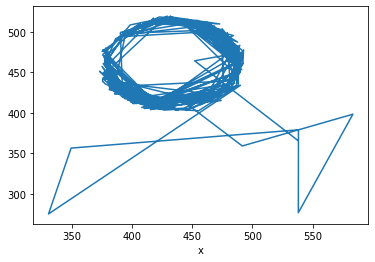

In [10]:
scorer=df.columns.get_level_values(0)[0]
df[scorer]['head'].plot(x='x', y='y', legend=False)

In [ ]:
# Extract outliers

In [ ]:
import os
destination_folder='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeletons_to_correct/'
#os.mkdir(destination_folder)
#videofile_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff.avi'
deeplabcut.extract_outlier_frames(path_config_file,videofile_path, outlieralgorithm='jump', automatic=True)

In [ ]:
['/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-06-05_16-46-41_worm1-channel-0-bigtiff.avi',